Task 1: Data Understanding and Visualization:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Week5/FruitinAmazon.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [ ]:
train_dir = "dataset/FruitinAmazon/train"

# Check structure
print(os.listdir("dataset"))
print(os.listdir(train_dir))

['FruitinAmazon']
['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


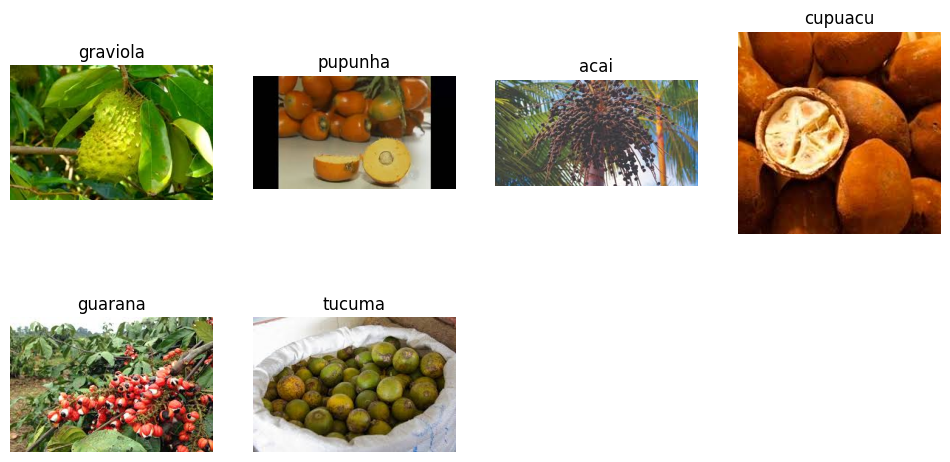

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

Check for Corrupted Image

In [ ]:
corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2: Loading and Preprocessing Image Data in keras

In [ ]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Task 3 - Implement a CNN

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])


Task 4: Compile the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 4: Train the Model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.1846 - loss: 2.0269

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 575ms/step - accuracy: 0.1944 - loss: 2.1388 - val_accuracy: 0.1667 - val_loss: 1.8283
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.1250 - loss: 2.0674 - val_accuracy: 0.1667 - val_loss: 1.7623
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.1487 - loss: 1.7950

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 616ms/step - accuracy: 0.1806 - loss: 1.7800 - val_accuracy: 0.4444 - val_loss: 1.7468
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 827ms/step - accuracy: 0.2778 - loss: 1.7510 - val_accuracy: 0.3333 - val_loss: 1.6978
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step - accuracy: 0.3333 - loss: 1.7115 - val_accuracy: 0.2778 - val_loss: 1.6471
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 489ms/step - accuracy: 0.2917 - loss: 1.6658 - val_accuracy: 0.2778 - val_loss: 1.5569
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 451ms/step - accuracy: 0.2778 - loss: 1.6736 - val_accuracy: 0.4444 - val_loss: 1.5254
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 0.2778 - loss: 1.6684 - val_accuracy: 0.4444 - val_loss: 1.5449
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - accuracy: 0.4167 - loss: 1.5735 - val_accuracy: 0.2778 - val_loss: 1.5700
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 0.3194 - loss: 1.5502 - val_accuracy: 0.3889 - val_loss: 1.4649
Ep

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 519ms/step - accuracy: 0.4583 - loss: 1.3402 - val_accuracy: 0.5556 - val_loss: 1.3985
Epoch 17/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 841ms/step - accuracy: 0.4028 - loss: 1.3970 - val_accuracy: 0.5000 - val_loss: 1.4234
Epoch 18/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 462ms/step - accuracy: 0.3889 - loss: 1.4914 - val_accuracy: 0.3889 - val_loss: 1.3653
Epoch 19/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 971ms/step - accuracy: 0.5139 - loss: 1.2454 - val_accuracy: 0.4444 - val_loss: 1.3444
Epoch 20/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.4647 - loss: 1.2848

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 497ms/step - accuracy: 0.4722 - loss: 1.2703 - val_accuracy: 0.6111 - val_loss: 1.4202
Epoch 21/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 753ms/step - accuracy: 0.4722 - loss: 1.3229 - val_accuracy: 0.5000 - val_loss: 1.3766
Epoch 22/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 858ms/step - accuracy: 0.4722 - loss: 1.3197 - val_accuracy: 0.4444 - val_loss: 1.4240
Epoch 23/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 467ms/step - accuracy: 0.4722 - loss: 1.2680 - val_accuracy: 0.5000 - val_loss: 1.4359
Epoch 24/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 455ms/step - accuracy: 0.5694 - loss: 1.1554 - val_accuracy: 0.5000 - val_loss: 1.3077
Epoch 25/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 457ms/step - accuracy: 0.5972 - loss: 1.0729 - val_accuracy: 0.5000 - val_loss: 1.2352


Task 5: Evaluate the Model

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5000 - loss: 1.2352
Accuracy: 0.5


Task 6: Save and Load the Model

In [ ]:
model.save("final_model.keras")

In [ ]:
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Task 7: Predictions and Classification Report

In [ ]:
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.5000 - loss: 1.2352
Loaded Model Accuracy: 0.5


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
              precision    recall  f1-score   support

        acai       0.33      1.00      0.50         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.75      1.00      0.86         3
     guarana       0.50      0.60      0.55         5
     pupunha       0.50      0.25      0.33         4
      tucuma       0.33      0.33      0.33         3

    accuracy                           0.50        18
   macro avg       0.40      0.53      0.43        18
weighted avg       0.45      0.50      0.45        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Keys in history.history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


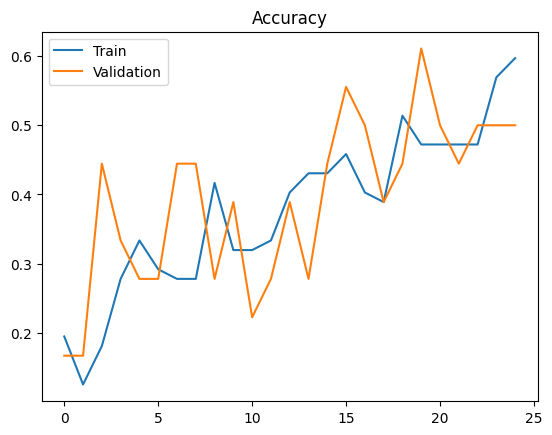

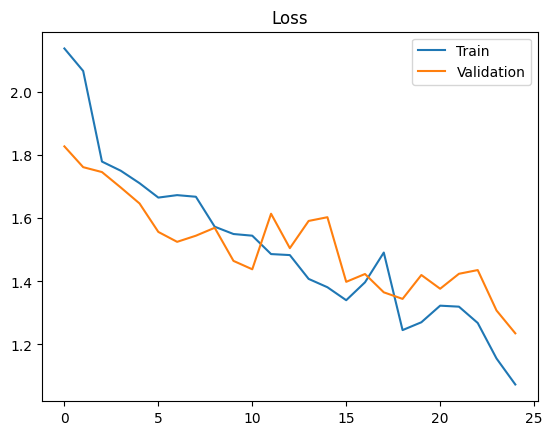

In [ ]:
import matplotlib.pyplot as plt

print("Keys in history.history:", history.history.keys())

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()